In [20]:
import pandas as pd
import numpy as np

from Database.DB_reader import Database
from sqlalchemy import text

In [21]:
db = Database()
conn = db.connection_string

`date`: trades after date

In [22]:
date = '2025-02-01'

In [23]:
stmt = f'''SELECT execution_time, trade_id, algo_id, price, quantity, buy_delivery_area, sell_delivery_area, product_id
FROM algo.strategy_trades
where execution_time > '{date}';
'''

In [24]:
db._connect()
df = pd.read_sql(text(stmt), db.engine)
db._disconnect()

Connected to the database postgre
Disconnected from the database postgre


In [25]:
df['quantity'] = df['quantity'] * (lambda srs: pd.Series([1 if x else -1 for x in srs], index=df.index))(df['buy_delivery_area'].astype(bool))

#### spbmark_m_1

-1.7000000000000086


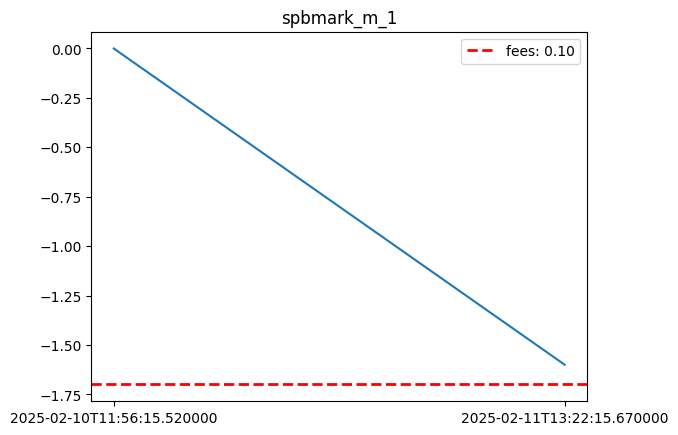

In [26]:
subspace = df[df['algo_id'] == 'spbmark_m_1']
subspace.set_index('execution_time', inplace=True)
subspace = subspace.sort_index()
subspace = subspace.drop(subspace.index[2])
subspace['position'] = subspace['quantity'].cumsum()
subspace['prev_price'] = subspace['price'].shift(1)
subspace['returns'] = subspace.apply(lambda row: (row['prev_price'] - row['price']) * row['quantity'] if row['position'] == 0 else np.nan, axis=1)
import matplotlib.pyplot as plt

fees = subspace.value_counts(subset=['position'])[0]*0.05

print(subspace['returns'].sum()-fees)

plt.plot(subspace['returns'].dropna().cumsum())
plt.axhline(subspace['returns'].sum()-fees, color='r', linestyle='dashed', linewidth=2, label=f'fees: {fees:.2f}')
# Add a legend
plt.legend()
plt.title('spbmark_m_1')
# Show plot
plt.show()

In [27]:
subspace

,trade_id,algo_id,price,quantity,buy_delivery_area,sell_delivery_area,product_id,position,prev_price,returns
execution_time,,,,,,,,,,
2025-02-10T11:51:02.805000,7347858,spbmark_m_1,112.10,-1,,10641710,10000104_255,-1,NaN,NaN
2025-02-10T11:56:15.520000,EDEBM032025:20250210:2916:1410600B,spbmark_m_1,112.10,1,10641710,,10000104_255,0,112.1,0.0
2025-02-11T12:04:05.456000,EDEBM032025:20250211:2413:1210100S,spbmark_m_1,110.80,-1,,10641710,10000104_255,-1,112.1,NaN
2025-02-11T13:22:15.670000,8127592,spbmark_m_1,112.40,1,10641710,,10000104_255,0,110.8,-1.6
2025-02-11T13:24:10.120000,EDEBM032025:20250211:3454:1710400S,spbmark_m_1,112.71,-1,,10641710,10000104_255,-1,112.4,NaN


#### spbmark_m_2

In [28]:
algo_id = 'spbmark_m_2'
subspace = df[df['algo_id'] == algo_id]
subspace.set_index('execution_time', inplace=True)
subspace = subspace.sort_index()
subspace['position'] = subspace['quantity'].cumsum()
subspace['prev_price'] = subspace['price'].shift(1)
subspace['returns'] = subspace.apply(lambda row: (row['prev_price'] - row['price']) * row['quantity'] if row['position'] == 0 else np.nan, axis=1)
import matplotlib.pyplot as plt


fees = subspace.value_counts(subset=['position'])[0]*0.05
plt.plot(subspace['returns'].dropna().cumsum())
plt.axhline(subspace['returns'].sum()-fees, color='r', linestyle='dashed', linewidth=2, label=f'fees: {fees:.2f}')

print(subspace['returns'].sum()-fees)

# Add a legend
plt.legend()
plt.title(algo_id)
# Show plot
plt.show()

KeyError: 0

0.19500000000000453


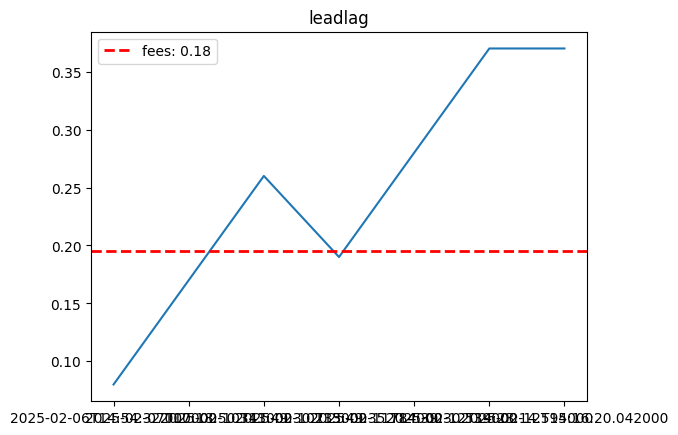

In [29]:
subspace = df[df['algo_id'] == 'arbitrage-de-cal-1']
subspace.set_index('execution_time', inplace=True)
subspace = subspace.sort_index()
subspace['position'] = subspace['quantity'].cumsum()
subspace['prev_price'] = subspace['price'].shift(1)
subspace['returns'] = subspace.apply(lambda row: (row['prev_price'] - row['price']) * row['quantity'] if row['position'] == 0 else np.nan, axis=1)
import matplotlib.pyplot as plt

fees = subspace.value_counts(subset=['position'])[0]*0.025
plt.plot(subspace['returns'].dropna().cumsum())
plt.axhline(subspace['returns'].sum()-fees, color='r', linestyle='dashed', linewidth=2, label=f'fees: {fees:.2f}')

print(subspace['returns'].sum()-fees)

# Add a legend
plt.legend()
plt.title('leadlag')
# Show plot
plt.show()

In [ ]:
subspace